#**Attention_1 : Simple Dense Attention**

In [1]:
import math
import torch
import torch.nn as nn

def Attention_1(Q, K, V):

    d_k = Q.size(-1)
    seq_len = Q.size(0)
    scores = torch.matmul(Q, K.T) / math.sqrt(d_k)

    for i in range(seq_len):
        for j in range(i+1, seq_len):
            scores[i][j] = float("-inf")

    attn_weights = torch.softmax(scores, dim=-1)

    output = torch.matmul(attn_weights, V)

    return output, scores

#**Attention_2 : Sliding Window Attention**

In [2]:

def Attention_2(Q, K, V, Window_size):

    d_k = Q.size(-1)
    seq_len = Q.size(0)

    scores = torch.full((seq_len, seq_len), float("-inf"))

    for i in range(seq_len):
        for j in range(max(0, i + 1 - Window_size), i + 1):
            scores[i][j] = torch.matmul(Q[i], K[j]) / math.sqrt(d_k)

    attn_weights = torch.softmax(scores, dim=-1)

    output = torch.matmul(attn_weights, V)

    return output, scores

#**Attention_3 : Improved Big-bird Attention**

In [3]:
def Attention_3(Q, K, V, Window_size, Global_size, Random_size):

    d_k = Q.size(-1)
    seq_len = Q.size(0)

    scores = torch.full((seq_len, seq_len), float("-inf"))

    for i in range(seq_len):
        for j in range(max(0, i + 1 - Window_size), i + 1):
            scores[i][j] = torch.matmul(Q[i], K[j]) / math.sqrt(d_k)

        for k in range(Random_size):
            rand_index = torch.randint(0, seq_len, ()).item()
            scores[i][rand_index] = torch.matmul(Q[i], K[rand_index]) / math.sqrt(d_k)

    Global_scores = torch.where(
        scores == float("-inf"),
        0.0,
        scores
    ).sum(dim=0)

    Global_indexes = torch.topk(Global_scores, Global_size).indices

    for i in range(Global_size):
        for j in range(seq_len):
            if Global_indexes[i] <= j:
                scores[j][Global_indexes[i]] = torch.matmul(
                    Q[j], K[Global_indexes[i]]
                ) / math.sqrt(d_k)

    attn_weights = torch.softmax(scores, dim=-1)

    output = torch.matmul(attn_weights, V)

    return output, scores

#**Correctness Harness**



In [4]:
def Correctness_harnesss(Q, K, V, Window_size, Global_size, Random_size):
  _,s1 = Attention_1(Q, K, V)
  _,s2 = Attention_2(Q, K, V, Window_size)
  _,s3 = Attention_3(Q, K, V, Window_size, Global_size, Random_size)
  seq_len = Q.size(0)
  Flag2,Flag3 = False,False

  for i in range(seq_len):

      for j in range(max(0, i + 1 - Window_size), i + 1):
          v1_2 = (s1[i][j] -s2[i][j]).item()
          if abs(v1_2)>1e-4:
              print("Attention_2 is false")
              Flag2 = True
              break
      if Flag2==True:
          break

  for i in range(seq_len):
        for j in range(max(0, i + 1 - Window_size), i + 1):
            v1_3 = (s1[i][j] -s3[i][j]).item()
            if abs(v1_3)>1e-4:
                print("Attention_3 is false")
                Flag3 = True
                break
        if Flag3==True:
            break

#**Metrics Benchmarking**

In [5]:
import time
import tracemalloc
import matplotlib.pyplot as plt

d_k = 16
d_v = 32

Window_size, Global_size, Random_size = 8, 5, 5

#testing
for i in range(3,8):
  seq_len = 2**i
  Q = torch.randn(seq_len, d_k)
  K = torch.randn(seq_len, d_k)
  V = torch.randn(seq_len, d_v)
  Attention_1(Q, K, V)
  Attention_2(Q, K, V, Window_size)
  Attention_3(Q, K, V, Window_size, Global_size, Random_size)

metrics = torch.zeros(3, 5, 2)

for i in range(8, 13):

    seq_len = 2**i
    idx = i - 8

    Q = torch.randn(seq_len, d_k)
    K = torch.randn(seq_len, d_k)
    V = torch.randn(seq_len, d_v)

    # Attention 1
    tracemalloc.start()
    start = time.perf_counter()

    Attention_1(Q, K, V)

    elapsed = time.perf_counter() - start
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    metrics[0][idx][0] = elapsed
    metrics[0][idx][1] = peak

    # Attention 2
    tracemalloc.start()
    start = time.perf_counter()

    Attention_2(Q, K, V, Window_size)

    elapsed = time.perf_counter() - start
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    metrics[1][idx][0] = elapsed
    metrics[1][idx][1] = peak

    # Attention 3
    tracemalloc.start()
    start = time.perf_counter()

    Attention_3(Q, K, V, Window_size, Global_size, Random_size)

    elapsed = time.perf_counter() - start
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    metrics[2][idx][0] = elapsed
    metrics[2][idx][1] = peak

#**Plotting Benchmark**

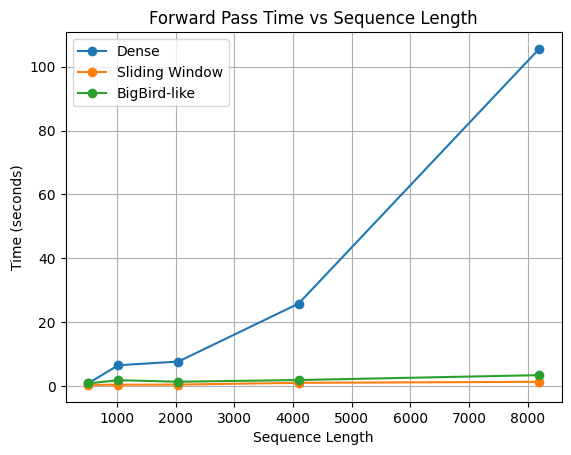

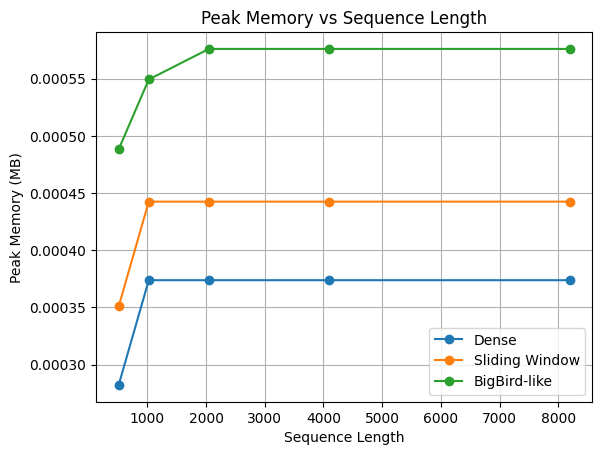

In [6]:
seq_lengths = [512, 1024, 2048, 4096, 8192]

# Time plot
plt.figure()
plt.plot(seq_lengths, metrics[0, :, 0], marker='o', label='Dense')
plt.plot(seq_lengths, metrics[1, :, 0], marker='o', label='Sliding Window')
plt.plot(seq_lengths, metrics[2, :, 0], marker='o', label='BigBird-like')

plt.xlabel("Sequence Length")
plt.ylabel("Time (seconds)")
plt.title("Forward Pass Time vs Sequence Length")
plt.legend()
plt.grid()
plt.show()

# Memory plot
plt.figure()
plt.plot(seq_lengths, metrics[0, :, 1] / (1024**2), marker='o', label='Dense')
plt.plot(seq_lengths, metrics[1, :, 1] / (1024**2), marker='o', label='Sliding Window')
plt.plot(seq_lengths, metrics[2, :, 1] / (1024**2), marker='o', label='BigBird-like')

plt.xlabel("Sequence Length")
plt.ylabel("Peak Memory (MB)")
plt.title("Peak Memory vs Sequence Length")
plt.legend()
plt.grid()
plt.show()

#**Character Tokenization and Embeddding**

In [7]:
import torch
import torch.nn as nn
from google.colab import files

uploaded = files.upload()

# TinyShakespeare text
with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

# All unique characters
chars = sorted(list(set(text)))
vocab_size = len(chars)

# Character <-> integer mappings
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

# Convert entire text to integer IDs
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)

# 64-dimensional character embeddings
n_embd = 64
token_embedding = nn.Embedding(vocab_size, n_embd)

print("Vocabulary size:", vocab_size)
print("Embedding shape:", token_embedding.weight.shape)

Saving input.txt to input.txt
Vocabulary size: 65
Embedding shape: torch.Size([65, 64])


#**Variable initializations**

In [8]:
train_length = 128
batch_size = 32
n_pos_embd = 64

position_list = torch.arange(0, train_length, dtype=torch.long)

pos_embedding = nn.Embedding(train_length, n_pos_embd)

n_QK=32
n_V=64


#**Layer 1**

In [14]:
Qc= nn.Linear(n_embd, n_QK)
Kc= nn.Linear(n_embd, n_QK)
Vc= nn.Linear(n_embd, n_V)

ix = torch.randint( 0, len(data) - train_length, (batch_size,) )

batch_input = torch.stack([ data[i:i + train_length] for i in ix ])

print("Batch input shape:", batch_input.shape)

batch_embedding = token_embedding(batch_input)

print("Token embedding shape:", batch_embedding.shape)

pos_emb = pos_embedding(position_list)

print("Position embedding shape:", pos_emb.shape)

batch_embedding = batch_embedding + pos_emb

print("After positional embedding:", batch_embedding.shape)

Q_t = Qc(batch_embedding)
K_t = Kc(batch_embedding)
V_t = Vc(batch_embedding)

print("Q shape:", Q_t.shape)
print("K shape:", K_t.shape)
print("V shape:", V_t.shape)

outputs = []

for i in range(batch_size):
    output, scores = Attention_2(Q_t[i], K_t[i], V_t[i], Window_size=8)
    outputs.append(output)

output_L1 = torch.stack(outputs)

print(output_L1.shape)

x_L1 = batch_embedding + output_L1

FFN_1 = nn.Sequential( nn.Linear(n_embd, 4 * n_embd), nn.ReLU(), nn.Linear(4 * n_embd, n_embd) )

ffn_output_L1 = FFN_1(x_L1)

x_L1_final = x_L1 + ffn_output_L1

print("Layer 1 output:", x_L1_final.shape)

Batch input shape: torch.Size([32, 128])
Token embedding shape: torch.Size([32, 128, 64])
Position embedding shape: torch.Size([128, 64])
After positional embedding: torch.Size([32, 128, 64])
Q shape: torch.Size([32, 128, 32])
K shape: torch.Size([32, 128, 32])
V shape: torch.Size([32, 128, 64])
torch.Size([32, 128, 64])
Layer 1 output: torch.Size([32, 128, 64])


#**Layer 2**

In [15]:
Qc_2 = nn.Linear(n_embd, n_QK)
Kc_2 = nn.Linear(n_embd, n_QK)
Vc_2 = nn.Linear(n_embd, n_V)

Q_t2 = Qc_2(x_L1_final)
K_t2 = Kc_2(x_L1_final)
V_t2 = Vc_2(x_L1_final)

print("Q2:", Q_t2.shape)
print("K2:", K_t2.shape)
print("V2:", V_t2.shape)


# -------------------------
# Attention
# -------------------------

outputs_L2 = []

for i in range(batch_size):
    output, scores = Attention_2( Q_t2[i], K_t2[i], V_t2[i], Window_size=8)
    outputs_L2.append(output)

output_L2 = torch.stack(outputs_L2)

print("Attention L2:", output_L2.shape)


# -------------------------
# Attention residual
# -------------------------

x_L2 = x_L1_final + output_L2

print("After attention residual L2:", x_L2.shape)


# -------------------------
# Feed Forward Network
# -------------------------

FFN_2 = nn.Sequential( nn.Linear(n_embd, 4 * n_embd), nn.ReLU(), nn.Linear(4 * n_embd, n_embd) )

ffn_output_L2 = FFN_2(x_L2)


# -------------------------
# FFN residual
# -------------------------

x_final = x_L2 + ffn_output_L2

print("Final Transformer output:", x_final.shape)

Q2: torch.Size([32, 128, 32])
K2: torch.Size([32, 128, 32])
V2: torch.Size([32, 128, 64])
Attention L2: torch.Size([32, 128, 64])
After attention residual L2: torch.Size([32, 128, 64])
Final Transformer output: torch.Size([32, 128, 64])


#**Probability Conversion**

In [11]:
lm_head = nn.Linear(n_embd, vocab_size)

logits = lm_head(x_final)

print("Logits shape:", logits.shape)\

targets = torch.stack([
    data[i + 1:i + train_length + 1]
    for i in ix
])

print("Targets shape:", targets.shape)

loss = nn.functional.cross_entropy(
    logits.view(-1, vocab_size),
    targets.view(-1)
)

print("Loss:", loss.item())

Logits shape: torch.Size([32, 128, 65])
Targets shape: torch.Size([32, 128])
Loss: 4.55222225189209


#**Training function definition**


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

optimizer = torch.optim.Adam(
    list(token_embedding.parameters()) +
    list(pos_embedding.parameters()) +
    list(Qc.parameters()) +
    list(Kc.parameters()) +
    list(Vc.parameters()) +
    list(Qc_2.parameters()) +
    list(Kc_2.parameters()) +
    list(Vc_2.parameters()) +
    list(FFN_1.parameters()) +
    list(FFN_2.parameters()) +
    list(lm_head.parameters()),
    lr=1e-3
)

optimizer.zero_grad()
loss.backward()
optimizer.step()
print("Updated!")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
token_embedding = token_embedding.to(device)
pos_embedding = pos_embedding.to(device)

Qc = Qc.to(device)
Kc = Kc.to(device)
Vc = Vc.to(device)

Qc_2 = Qc_2.to(device)
Kc_2 = Kc_2.to(device)
Vc_2 = Vc_2.to(device)

FFN_1 = FFN_1.to(device)
FFN_2 = FFN_2.to(device)

lm_head = lm_head.to(device)

cpu
Updated!
cpu
CPU
